<a href="https://colab.research.google.com/github/Adriungs/SQL/blob/main/SQL_B%C3%81SICO/3_OperadoresL%C3%B3gicos_y_Restricciones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center>
<font size = '4'><u><b>FRAGMENTACION DE DATAFRAME</b></u></font>
</center>

En este caso las explicaciónes de los codigos de python no son importantes,sin embargo, si voy a detallar que lo que hizo el codigo en python es crearme 3 tablas dividiendo el contenido del archivo.

 **¿Porque fragmentamos el dataframe?**

  Como necesitamos unir multiples tablas para futuras prácticas lo conveniente es dividirlo usando solo una base de datos.

Otras bases de datos podrian no estar correlacionadas y estaremos juntando datos diferentes ó que nada tienen que ver con lo que estamos analizando.

En las aplicaciones reales se usan multiples tablas de diferentes sectores eso es lo que hicimos al fragmentar.

Si lo pensamos en aplicaciones reales hay tres sectores que requieren diferentes tablas:


1.   Clientes
2.   Productos
3.   Ventas



In [1]:
#Nueva base de datos
!pip install jupysql --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.8/192.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.5/268.5 kB 15.9 MB/s eta 0:00:00


In [2]:
import pandas as pd
import sqlite3

# 1. Cargar el archivo con tus columnas reales
df_original = pd.read_csv('retail_ferreteria.csv')

# 2. Normalización ajustada a tu dataset

clientes = df_original[['id_cliente', 'nombre_cliente', 'provincia']].drop_duplicates()

productos = df_original[['producto', 'categoria', 'precio_unitario']].drop_duplicates()

ventas = df_original[['id_venta', 'fecha_hora', 'id_cliente', 'producto', 'cantidad', 'total_venta', 'sucursal', 'medio_pago']]

# 3. Guardar en el motor SQLite
conn = sqlite3.connect('ferreteria.db')

try:
  clientes.to_sql('clientes', conn, if_exists='replace', index=False)
  productos.to_sql('productos', conn, if_exists='replace', index=False)
  ventas.to_sql('ventas', conn, if_exists='replace', index=False)
finally:
    conn.close()  # <-- Esto libera el archivo y evita el error "database is locked"

print("¡Base de datos 'ferreteria.db' creada y liberada con éxito!")



¡Base de datos 'ferreteria.db' creada y liberada con éxito!


In [3]:
%load_ext sql
%sql sqlite:///ferreteria.db
%config SqlMagic.feedback = False
%config SqlMagic.displaylimit = 0

Connecting to 'sqlite:///ferreteria.db'

<center>
<font size = '6' color =violet><u><b>Operadores lógicos — AND, OR y NOT<b/></u></font>
</center>

En la lección anterior se filtraron datos con WHERE usando condiciones simples como =, >, < o !=.

Pero en la vida real, muchas veces necesitamos combinar varias condiciones al mismo tiempo.

<u><b>Para eso utilizamos los operadores lógicos:</b></u>

* AND → ambas condiciones deben cumplirse.
* OR → se cumple una u otra condición.
* NOT → excluye resultados que cumplen una condición

<font size = '4' color =violet><u><b>Sintaxis General<b/></u></font>

---
SELECT columnas

FROM tabla

WHERE condición1 AND/OR/NOT condición2;

---

<center>
<font size = '6' color =violet><u><b>Consultas con restricciones<b/></u></font>
</center>

A continuación, mostramos algunos operadores comunes específicos para datos de texto:


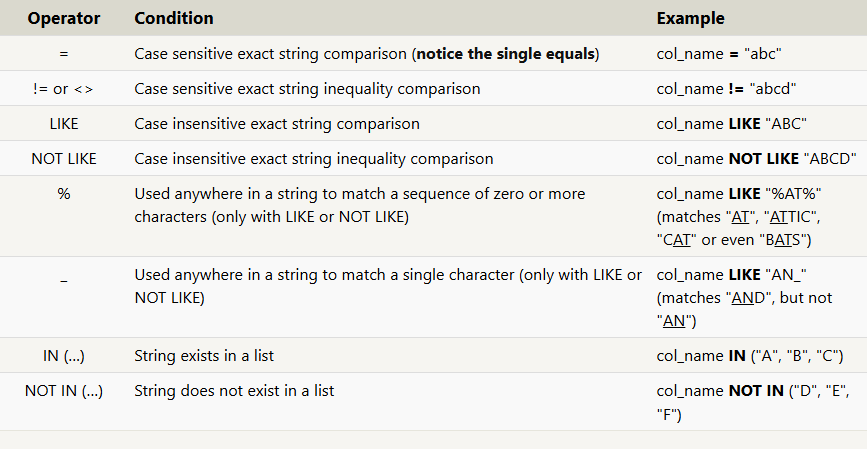

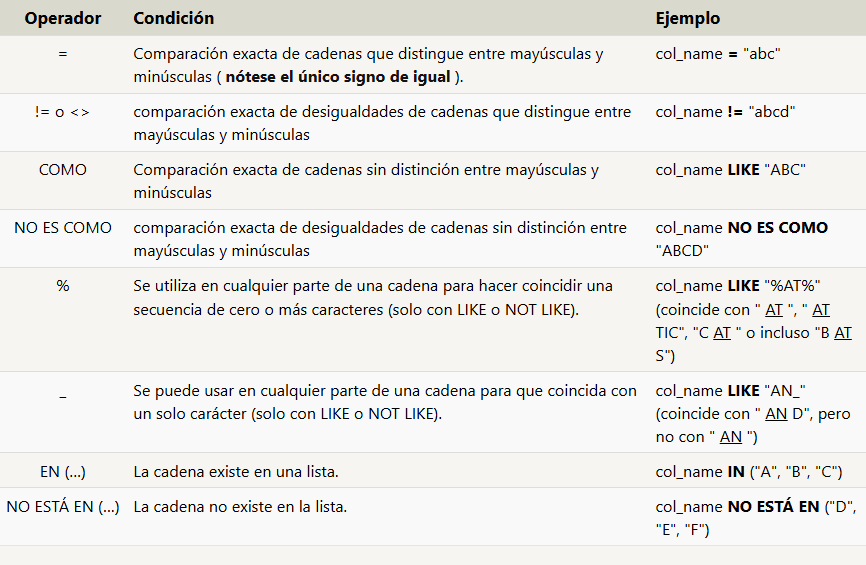




Todas las cadenas deben ir entre comillas para que el analizador de consultas pueda distinguir las palabras de la cadena de las palabras clave SQL.

El operador LIKE en SQL utiliza el comodín % para representar cualquier cantidad de caracteres (incluyendo cero caracteres). El lugar donde coloques el % cambia por completo el resultado de tu búsqueda.

**LIKE** 'chocolate blanco%'

* <b>Qué busca:</b>

Registros que empiezan exactamente con
"chocolate blanco".

* <b>Ejemplos que encuentra:</b> "chocolate blanco", "chocolate blanco amargo", "chocolate blanco con nueces".

* <b>Ejemplos que ignora:</b>

 "un chocolate blanco", "chocolate negro".

---

**LIKE** '%choco'

* <b>Qué busca:</b>

 Registros que terminan exactamente con la palabra "choco".

* <b>Ejemplos que encuentra:</b>
 "choco", "mucho choco", "delichoco".

* <b>Ejemplos que ignora:</b>
 "chocolate", "choco blanco".

---

**LIKE** '%c'

* <b>Qué busca:</b>

 Registros que terminan con la letra "c".

* <b>Ejemplos que encuentra:</b>

  "choc", "bloc", "tic tac".
  
* <b>Ejemplos que ignora: </b>"chocolate", "casa", "blanco".

---

**LIKE** '%choco%'

* <b>Qué busca:</b>

 Registros que contienen la palabra "choco" en cualquier posición (al inicio, al medio o al final). Es la opción más abierta y usada para buscadores.

 * <b>Ejemplos que encuentra:</b> "chocolate blanco", "un chocoito", "puro choco".

 * <b>Ejemplos que ignora: </b>"blanco", "frutilla", "galletitas".




<center>
<font size = '6' color =violet><u><b>EJERCICIOS

OPERADORES LÓGICOS<b/></u></font>
</center>


<font size = '4' color =violet><u><b>usar AND<b/></u></font>

1.Identificar el nombre de los clientes y sus provincias

In [4]:
print(clientes)

      id_cliente                 nombre_cliente     provincia
0           2824            Benjamin Perez Diaz  Buenos Aires
1           2424          Amparo Paez Rodriguez       Mendoza
2           7873           Martina Diaz Gimenez       Córdoba
3           5552  Sr(a). Thiago Agustin Quiroga       Córdoba
4           5333          Tomàs Victoria Aguero  Buenos Aires
...          ...                            ...           ...
2995        4249      Tomàs Juan Ignacio Bustos       Córdoba
2996        7376      Emma Mia Valentina Castro  Buenos Aires
2997        1757         Jazmin Martina Navarro  Buenos Aires
2998        3365  Guillermina Juan Cruz Navarro      Santa Fe
2999        2536               Benjamin Vazquez       Mendoza

[3000 rows x 3 columns]


In [5]:
%%sql
SELECT nombre_cliente, provincia
FROM clientes
WHERE provincia = 'Mendoza' AND nombre_cliente = 'Amparo Paez Rodriguez'

nombre_cliente,provincia
Amparo Paez Rodriguez,Mendoza


2-Verificar que la cantidad vendida sea mayor a 3 y que
sea cintas métricas


In [6]:
%%sql
SELECT producto, cantidad
FROM ventas
WHERE producto = 'Cinta métrica' AND cantidad > 3.0
LIMIT 10

producto,cantidad
Cinta métrica,5.0
Cinta métrica,4.0
Cinta métrica,4.0
Cinta métrica,5.0
Cinta métrica,4.0
Cinta métrica,5.0
Cinta métrica,4.0
Cinta métrica,4.0
Cinta métrica,5.0
Cinta métrica,4.0


<font size = '4' color =violet><u><b>usar OR<b/></u></font>

3-Encontrar la sucursal en Palermo o el medio de pago donde sea en Efectivo

In [7]:
%%sql
SELECT id_venta, sucursal , medio_pago
FROM ventas
WHERE sucursal = 'Sucursal Palermo' OR medio_pago = 'Efectivo'
LIMIT 10

id_venta,sucursal,medio_pago
1,Sucursal Palermo,mercadopago
5,Sucursal Palermo,mercadopago
9,Sucursal Palermo,tarjeta_crédito
23,Sucursal Palermo,tarjeta_crédito
26,Sucursal Palermo,efectivo
31,Sucursal Palermo,mercadopago
37,Sucursal Palermo,transferencia
41,Sucursal Palermo,transferencia
54,Sucursal Palermo,mercadopago
60,Sucursal Palermo,tarjeta_crédito


<font size = '4' color =violet><u><b>usar NOT<b/></u></font>

4- Vamos a ver todas las sucursales que no sean de Palermo

In [8]:
%%sql
SELECT id_venta, sucursal
FROM ventas
WHERE NOT sucursal = 'Sucursal Palermo'
LIMIT 12

id_venta,sucursal
2,Sucursal Mendoza
3,Sucursal Córdoba
4,Sucursal Córdoba
6,Sucursal Córdoba
7,Sucursal Rosario
8,Sucursal Córdoba
10,Sucursal Córdoba
11,Sucursal Córdoba
12,Sucursal Mendoza
13,Sucursal Rosario


<font size = '4' color =violet><u><b>combinar AND y OR<b/></u></font>

4- Necesitamos saber las Llaves inglesas que sean mayor a 8 cantidades vendidas ó las Sierras circulares que su venta sea = 5

In [9]:
%%sql
SELECT id_venta, producto, cantidad
FROM ventas
WHERE (producto = 'Llave inglesa' AND cantidad > 8.0) OR (producto = 'Sierra circular' AND cantidad = 5.0)
LIMIT 13

id_venta,producto,cantidad
3,Sierra circular,5.0
5,Sierra circular,5.0
23,Sierra circular,5.0
47,Sierra circular,5.0
50,Sierra circular,5.0
141,Sierra circular,5.0
144,Sierra circular,5.0
186,Sierra circular,5.0
364,Sierra circular,5.0
453,Sierra circular,5.0


<font size = '4' color =violet><u><b>usar NOT con AND<b/></u></font>

Que no sean sucursales de Mendoza y que no sean sucursales de Córdoba



In [10]:
%%sql
SELECT id_venta, sucursal
FROM ventas
WHERE NOT sucursal = 'Sucursal Mendoza' AND NOT sucursal = 'Sucursal Córdoba'
LIMIT 10

id_venta,sucursal
1,Sucursal Palermo
5,Sucursal Palermo
7,Sucursal Rosario
9,Sucursal Palermo
13,Sucursal Rosario
14,Sucursal Rosario
15,Sucursal Rosario
23,Sucursal Palermo
25,Sucursal Rosario
26,Sucursal Palermo


In [11]:
print(clientes)

      id_cliente                 nombre_cliente     provincia
0           2824            Benjamin Perez Diaz  Buenos Aires
1           2424          Amparo Paez Rodriguez       Mendoza
2           7873           Martina Diaz Gimenez       Córdoba
3           5552  Sr(a). Thiago Agustin Quiroga       Córdoba
4           5333          Tomàs Victoria Aguero  Buenos Aires
...          ...                            ...           ...
2995        4249      Tomàs Juan Ignacio Bustos       Córdoba
2996        7376      Emma Mia Valentina Castro  Buenos Aires
2997        1757         Jazmin Martina Navarro  Buenos Aires
2998        3365  Guillermina Juan Cruz Navarro      Santa Fe
2999        2536               Benjamin Vazquez       Mendoza

[3000 rows x 3 columns]


<center>
<font size = '6' color =violet><u><b>EJERCICIOS

CONSULTAS CON     
RESTRICCIONES<b/></u></font>
</center>


1- Encuentra el producto Pintura látex 4L  pero sin escribir el nombre completo ya que tardarias mucho, si escribieras el nombre largo de cada producto

In [12]:
%%sql
SELECT id_cliente, producto
FROM ventas
WHERE producto LIKE 'Pintura%'
LIMIT 13

id_cliente,producto
4752,Pintura látex 4L
2876,Pintura látex 4L
2588,Pintura látex 4L
1993,Pintura látex 4L
9883,Pintura látex 4L
6700,Pintura látex 4L
9824,Pintura látex 4L
6383,Pintura látex 4L
5806,Pintura látex 4L
1349,Pintura látex 4L


2-Vas a encontrar todos los productos que tengan la palabra 'Pin'

In [13]:
%%sql
SELECT id_cliente, producto
FROM ventas
WHERE producto LIKE '%Pin%'
LIMIT 13

id_cliente,producto
4752,Pintura látex 4L
2040,Rodillo de pintura
2876,Pintura látex 4L
2588,Pintura látex 4L
1993,Pintura látex 4L
8454,Rodillo de pintura
9883,Pintura látex 4L
2113,Rodillo de pintura
4910,Rodillo de pintura
3608,Rodillo de pintura


3-Se nos mojo una hoja pero solo figura que termina en 'ar', tenemos que ver cual fue el producto que se llevaron

In [14]:
%%sql
SELECT id_cliente, producto
FROM ventas
WHERE producto LIKE '%ar'
LIMIT 13

id_cliente,producto
7873,Sierra circular
5333,Sierra circular
7227,Sierra circular
1009,Sierra circular
5092,Sierra circular
3724,Sierra circular
6279,Sierra circular
1757,Sierra circular
4185,Sierra circular
8478,Sierra circular
